# Bari- Hybrid Multimodal Anemia Detection System


**Components:**
1. **Tabular Model**
2. **Visual Model**
3. **Late Fusion**



## 1. Imports & Configuration

In [26]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
RANDOM_STATE = 42


#  Part 1: Tabular Model 

Process CBC blood test data

In [ ]:

df = pd.read_csv(r"C:\Users\USER\Capstone\Bari\data\Tabular\anemia.csv")
df.head()

print("Dataset Shape:", df.shape)

df.info()

df.describe()

missing = df.isnull().sum()
print(missing)


Dataset Shape: (710, 11)
<class 'pandas.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IMAGE_ID               710 non-null    str    
 1   HB_LEVEL               710 non-null    float64
 2   Severity               710 non-null    str    
 3   Age(Months)            710 non-null    int64  
 4   GENDER                 710 non-null    str    
 5   REMARK                 710 non-null    str    
 6   HOSPITAL               710 non-null    str    
 7   CITY/TOWN              710 non-null    str    
 8   MUNICIPALITY/DISTRICT  710 non-null    str    
 9   REGION                 710 non-null    str    
 10  COUNTRY                710 non-null    str    
dtypes: float64(1), int64(1), str(9)
memory usage: 129.0 KB
IMAGE_ID                 0
HB_LEVEL                 0
Severity                 0
Age(Months)              0
GENDER                   0
REMARK    

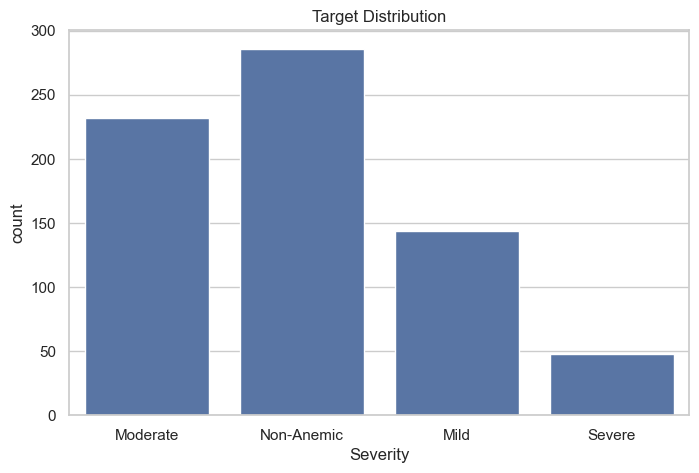

Severity
Non-Anemic    0.402817
Moderate      0.326761
Mild          0.202817
Severe        0.067606
Name: proportion, dtype: float64


In [28]:
# Target distribution
sns.countplot(x="Severity", data=df)
plt.title("Target Distribution")
plt.show()

print(df["Severity"].value_counts(normalize=True))

## 1.2 Load and Preprocess Tabular Data

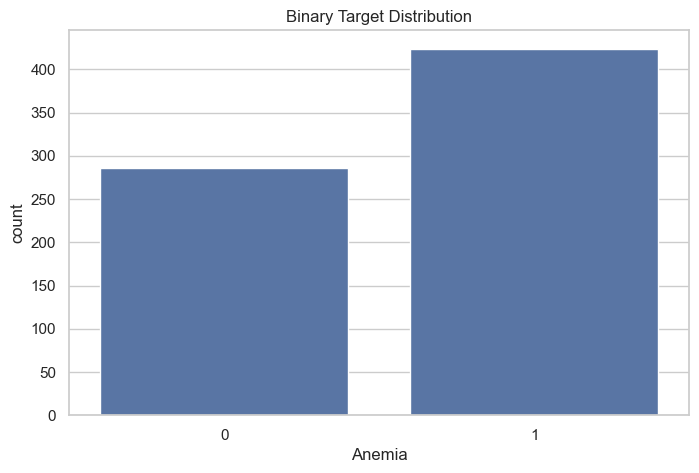

In [29]:
df["Severity"] = df["Severity"].str.lower()

df["Anemia"] = df["Severity"].apply(
    lambda x: 0 if "non" in x else 1
)

df["Anemia"].value_counts()

sns.countplot(x="Anemia", data=df)
plt.title("Binary Target Distribution")
plt.show()

## 1.3 Data Preprocessing

In [30]:
df = df.drop(columns=[
    "REMARK",
    "HOSPITAL",
    "CITY/TOWN",
    "MUNICIPALITY/DISTRICT",
    "REGION",
    "COUNTRY"
])

In [31]:
df["GENDER"] = df["GENDER"].map({
    "Male": 0,
    "Female": 1
})

In [32]:
df.head()

,IMAGE_ID,HB_LEVEL,Severity,Age(Months),GENDER,Anemia
0,Image_001,9.8,moderate,6,1,1
1,Image_002,9.9,moderate,24,0,1
2,Image_003,11.1,non-anemic,24,1,0
3,Image_004,12.5,non-anemic,12,0,0
4,Image_005,9.9,moderate,24,0,1


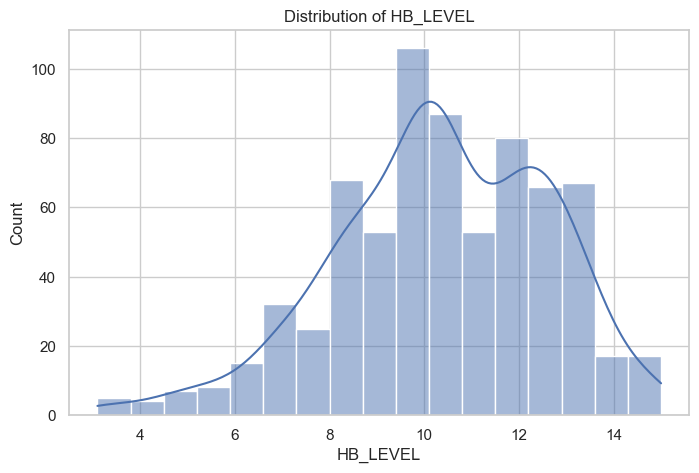

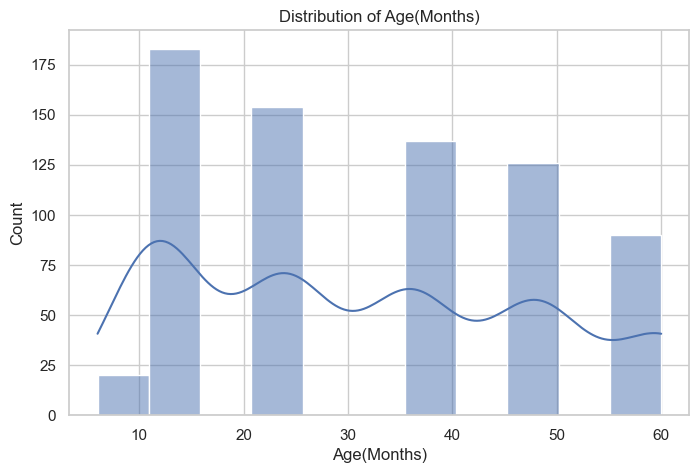

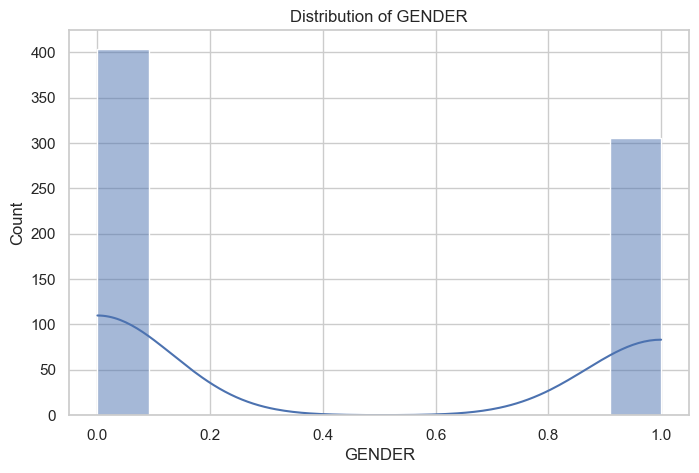

In [33]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if col != "Anemia":
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

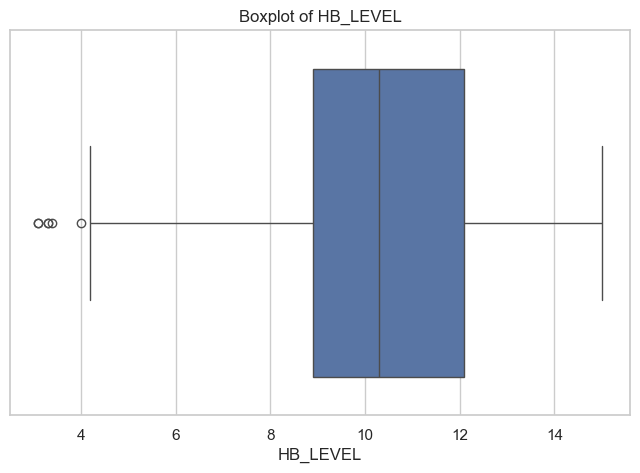

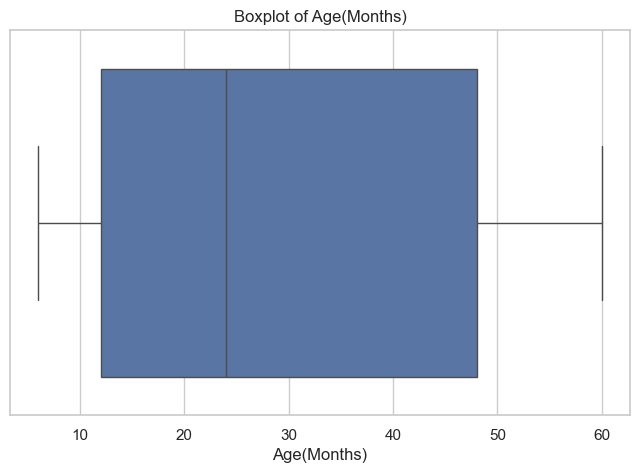

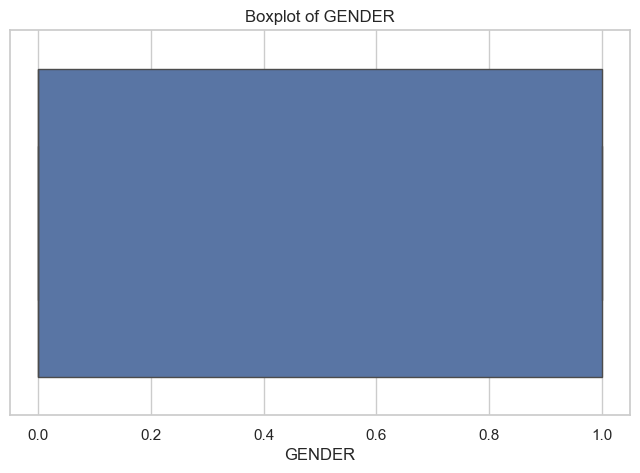

In [34]:
for col in numeric_cols:
    if col != "Anemia":
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

In [35]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return np.clip(series, lower, upper)

for col in numeric_cols:
    if col != "Anemia":
        df[col] = cap_outliers(df[col])

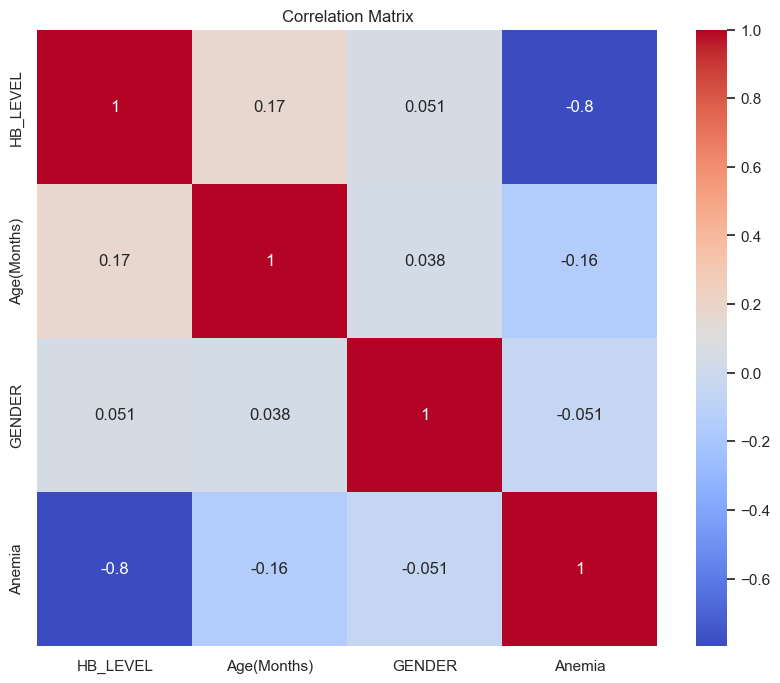

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [37]:
df.groupby("Severity")["HB_LEVEL"].describe()

,count,mean,std,min,25%,50%,75%,max
Severity,,,,,,,,
mild,144.0,10.345417,0.269615,10.0,10.10,10.30,10.525,10.93
moderate,232.0,8.682974,0.844949,7.0,8.00,8.75,9.500,9.98
non-anemic,286.0,12.533427,0.956516,11.0,11.90,12.45,13.175,15.00
severe,48.0,5.629167,0.970623,4.1,4.95,5.85,6.425,6.90


In [38]:
if "Hemoglobin" in df.columns and "RBC" in df.columns:
    df["Hb_RBC_Ratio"] = df["Hemoglobin"] / df["RBC"]

In [39]:
if "Gender" in df.columns:
    df["Gender"] = df["Gender"].map({"Male":0, "Female":1})

In [40]:
X = df.drop("Anemia", axis=1)
y = df["Anemia"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (568, 5)
Test shape: (142, 5)


In [42]:
X.dtypes

HB_LEVEL       float64
Age(Months)      int64
GENDER           int64
dtype: object

Training LogisticRegression...


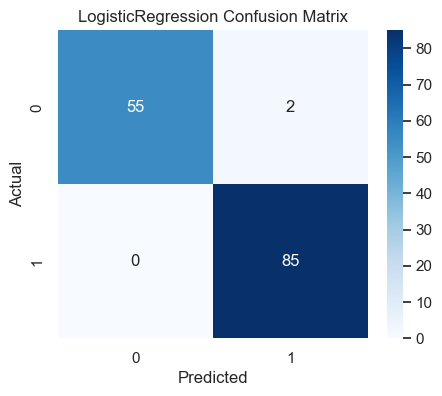

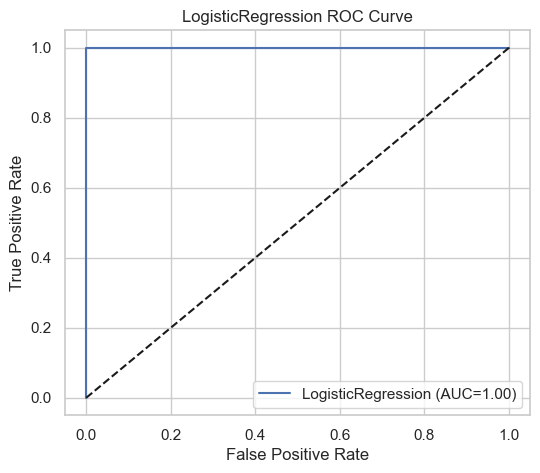

LogisticRegression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        57
           1       0.98      1.00      0.99        85

    accuracy                           0.99       142
   macro avg       0.99      0.98      0.99       142
weighted avg       0.99      0.99      0.99       142

----------------------------------------
Training RandomForest...


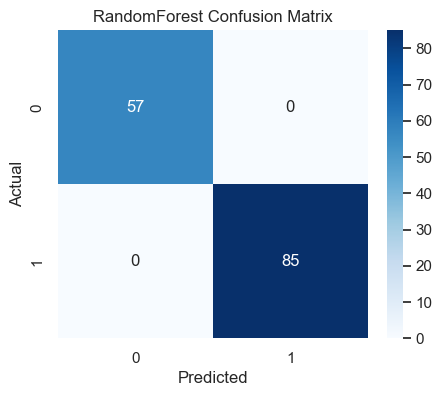

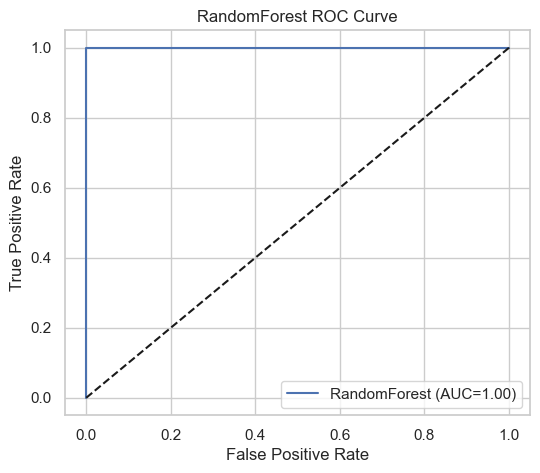

RandomForest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       1.00      1.00      1.00        85

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142

----------------------------------------
Training XGBoost...


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [01:58:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


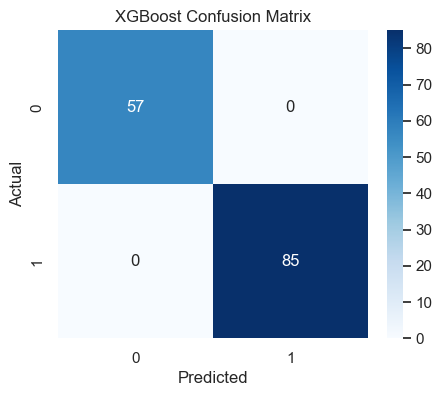

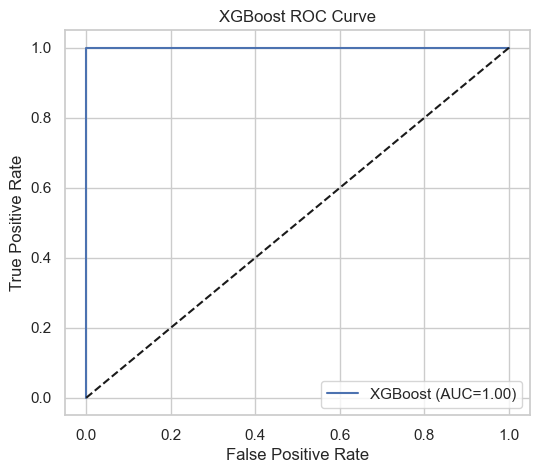

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       1.00      1.00      1.00        85

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142

----------------------------------------


,Accuracy,Precision,Recall,F1-score,F2-score,AUC
LogisticRegression,0.985915,0.977011,1.0,0.988372,0.995316,1.0
RandomForest,1.000000,1.000000,1.0,1.000000,1.000000,1.0
XGBoost,1.000000,1.000000,1.0,1.000000,1.000000,1.0


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 2. Split Data

# X, y = your features and labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# 3. Scale features and keep column names

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 4. Initialize models

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

models = {
    "LogisticRegression": logreg_model,
    "RandomForest": rf_model,
    "XGBoost": xgb_model
}

# 5. Train and evaluate

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Probabilities for ROC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else: 
        y_prob = model.decision_function(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    auc = roc_auc_score(y_test, y_prob)
    
    # Save metrics
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "F2-score": f2,
        "AUC": auc
    }
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()
    
    # Classification Report
    print(f"{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-"*40)
    
    joblib.dump(model, f"{name}_model.pkl")
#6. Save results summary

results_df = pd.DataFrame(results).T
results_df.to_csv("tabular_model_results.csv", index=True)
results_df


#  Part 2: Visual Model 

Process eye conjunctiva images 

Total images collected: 710
Classes found: {'Non-anemic', 'Anemic'}


C:\Users\USER\AppData\Local\Temp\ipykernel_26092\3823046015.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="pastel")


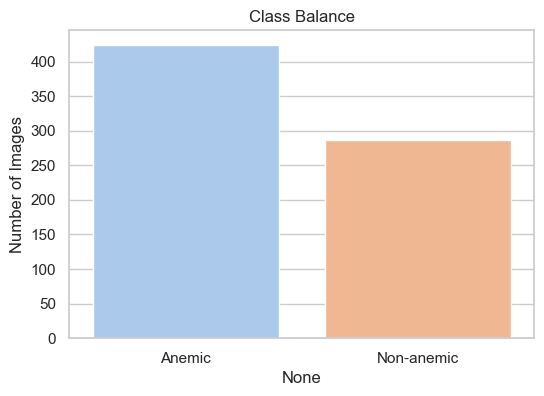

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd

image_folder = r"C:\Users\USER\Capstone\Bari\data\Images"

image_files = []
labels = []

for class_folder in os.listdir(image_folder):
    class_path = os.path.join(image_folder, class_folder)
    if os.path.isdir(class_path):  
        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_files.append(file_path)
                labels.append(class_folder)

print(f"Total images collected: {len(image_files)}")
print(f"Classes found: {set(labels)}")

class_counts = pd.Series(labels).value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="pastel")
plt.title("Class Balance")
plt.ylabel("Number of Images")
plt.show()


In [ ]:
import os
import pandas as pd

labels = [os.path.basename(os.path.dirname(p)) for p in image_files]
print(pd.Series(labels).value_counts())

Anemic        424
Non-anemic    286
Name: count, dtype: int64


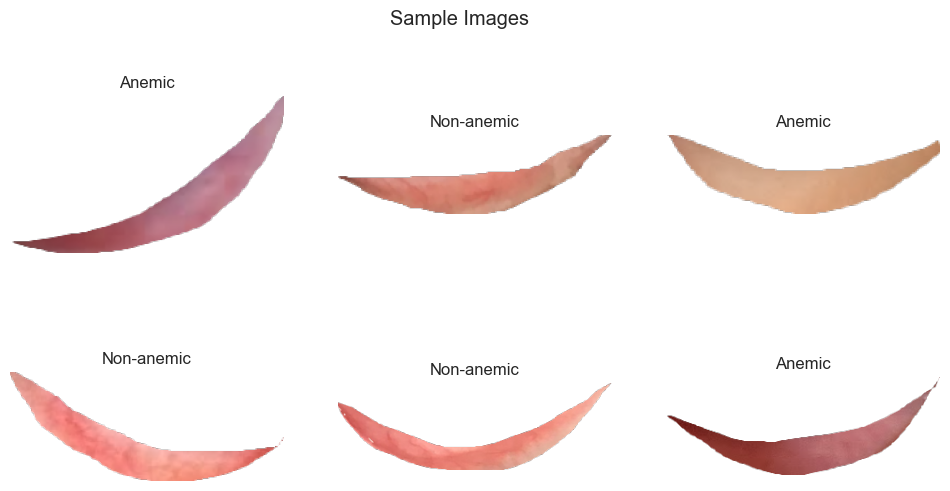

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

class_dict = {}
for img_path in image_files:
    label = os.path.basename(os.path.dirname(img_path))
    class_dict.setdefault(label, []).append(img_path)

samples = []
for label, paths in class_dict.items():
    n = min(3, len(paths))
    samples.extend(random.sample(paths, n))

random.shuffle(samples)

# Display
plt.figure(figsize=(12,6))
for i, img_path in enumerate(samples):
    img = Image.open(img_path)
    label = os.path.basename(os.path.dirname(img_path))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.suptitle("Sample Images")
plt.show()

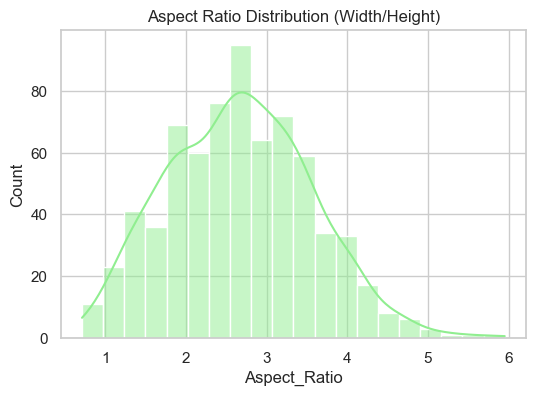

Potentially problematic images (too small):
     Width  Height  Aspect_Ratio
22     208      49      4.244898
29     138      48      2.875000
41     151      46      3.282609
107    182      49      3.714286
109    111      42      2.642857
..     ...     ...           ...
666    211      46      4.586957
667    211      46      4.586957
685    172      37      4.648649
687    145      40      3.625000
708    166      42      3.952381

[64 rows x 3 columns]


In [ ]:
sizes_df["Aspect_Ratio"] = sizes_df["Width"] / sizes_df["Height"]
plt.figure(figsize=(6,4))
sns.histplot(sizes_df["Aspect_Ratio"], bins=20, kde=True, color='lightgreen')
plt.title("Aspect Ratio Distribution (Width/Height)")
plt.show()

outliers = sizes_df[(sizes_df["Width"] < 50) | (sizes_df["Height"] < 50)]
print(f"Potentially problematic images (too small):\n{outliers}")

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

data = []
for img_path in image_files:
    label = os.path.basename(os.path.dirname(img_path))
    data.append([img_path, label])

df_images = pd.DataFrame(data, columns=["path", "label"])

print(df_images["label"].value_counts())

df_images["label"] = df_images["label"].map({
    "Non-anemic": 0,
    "Anemic": 1
})

train_df, val_df = train_test_split(
    df_images,
    test_size=0.2,
    stratify=df_images["label"],
    random_state=42
)

print("Train distribution:\n", train_df["label"].value_counts())
print("Val distribution:\n", val_df["label"].value_counts())

label
Anemic        424
Non-anemic    286
Name: count, dtype: int64
Train distribution:
 label
1    339
0    229
Name: count, dtype: int64
Val distribution:
 label
1    85
0    57
Name: count, dtype: int64


In [ ]:
class AnemiaDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, pixel_shift=0):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.pixel_shift = pixel_shift  

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        
        if self.pixel_shift != 0:
            img_np = np.array(img).astype(np.float32)
            img_np = np.clip(img_np + self.pixel_shift, 0, 255)
            img = Image.fromarray(img_np.astype(np.uint8))
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

In [ ]:
image_folder = r"C:\Users\USER\Capstone\Bari\data\Images"
classes = ["Anemic", "Non-anemic"]
image_paths, labels = [], []

for i, cls in enumerate(classes):
    cls_folder = os.path.join(image_folder, cls)
    for img_name in os.listdir(cls_folder):
        image_paths.append(os.path.join(cls_folder, img_name))
        labels.append(i)

# Train/Validation split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_dataset = AnemiaDataset(train_paths, train_labels, transform=train_transform, pixel_shift=5)
val_dataset = AnemiaDataset(val_paths, val_labels, transform=val_transform)

In [ ]:
from torch.utils.data import WeightedRandomSampler

class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [79]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
import torch
from torchvision import models, transforms
from torch import nn, optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.alexnet(weights="AlexNet_Weights.IMAGENET1K_V1")

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(model.classifier[6].in_features, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

In [ ]:
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)  
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
    
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("-"*40)

Epoch 1/15
Train Loss: 0.5637
Validation Accuracy: 0.6338
----------------------------------------
Epoch 2/15
Train Loss: 0.5369
Validation Accuracy: 0.7676
----------------------------------------
Epoch 3/15
Train Loss: 0.5093
Validation Accuracy: 0.6479
----------------------------------------
Epoch 4/15
Train Loss: 0.5290
Validation Accuracy: 0.7324
----------------------------------------
Epoch 5/15
Train Loss: 0.4782
Validation Accuracy: 0.7887
----------------------------------------
Epoch 6/15
Train Loss: 0.5404
Validation Accuracy: 0.7113
----------------------------------------
Epoch 7/15
Train Loss: 0.4912
Validation Accuracy: 0.7394
----------------------------------------
Epoch 8/15
Train Loss: 0.4960
Validation Accuracy: 0.7042
----------------------------------------
Epoch 9/15
Train Loss: 0.4763
Validation Accuracy: 0.7606
----------------------------------------
Epoch 10/15
Train Loss: 0.4511
Validation Accuracy: 0.7606
----------------------------------------
Epoch 11/

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

model.eval()  
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:  
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)  
        preds = (probs > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

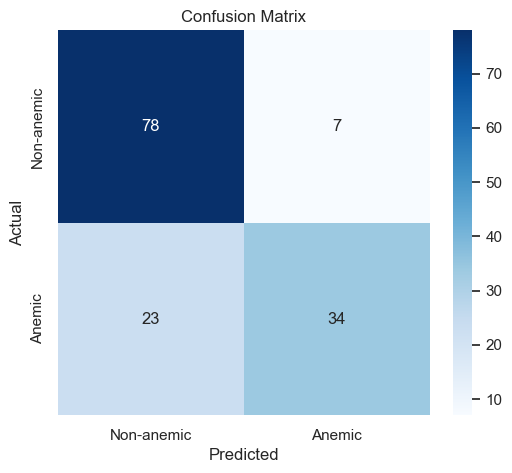

In [89]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-anemic", "Anemic"], yticklabels=["Non-anemic", "Anemic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:  
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())   

# Convert to numpy arrays
all_labels = np.array(all_labels).ravel()
all_preds = np.array(all_preds).ravel()
all_probs = np.array(all_probs).ravel()

In [94]:
print(classification_report(all_labels, all_preds,
                            target_names=["Non-anemic", "Anemic"]))

              precision    recall  f1-score   support

  Non-anemic       0.77      0.92      0.84        85
      Anemic       0.83      0.60      0.69        57

    accuracy                           0.79       142
   macro avg       0.80      0.76      0.77       142
weighted avg       0.80      0.79      0.78       142



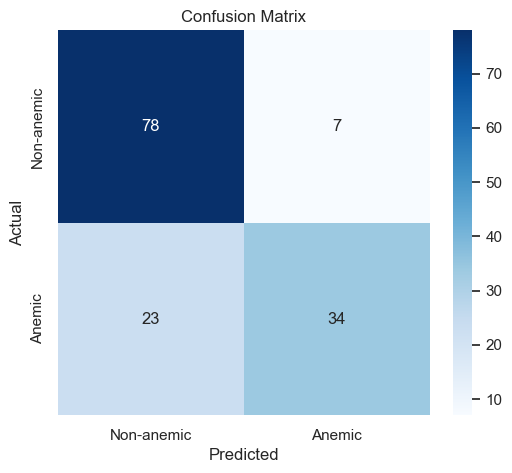

In [95]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-anemic", "Anemic"],
            yticklabels=["Non-anemic", "Anemic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

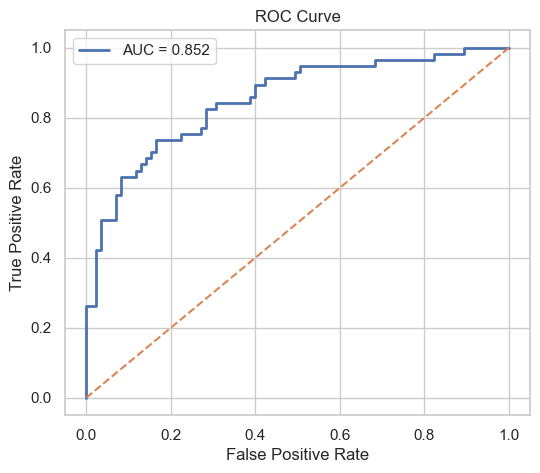

AUC Score: 0.8518059855521156


In [96]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)